# EV Charging Load Data — Cleaning Pipeline (Hourly Dataset)

**Input:** `data/interim/ev_unified_hourly.parquet` — 873 stations, Jan 2021 – Dec 2022, hourly resolution  
**Output:** `data/processed/ev_cleaned_hourly.parquet`

---

## Hourly Dataset Schema (22 columns confirmed)

| Column | Description |
|---|---|
| `customer_id` | Station identifier |
| `timestamp_hour` | Hour-level timestamp |
| `load_kwh_hourly` | Sum of observed 15-min values; NaN if all 4 quarters missing |
| `observed_quarters` | Count of non-null 15-min slots in this hour (0–4) |
| `missing_quarters` | 4 − observed_quarters |
| `is_dr_event` | True if any quarter in this hour was a DR event |
| `dr_performance_kwh_hourly` | Hourly DR performance (kWh) |
| `public_private`, `business_type`, `contract_type`, `detailed_type` | Station classification |
| `contract_power_kw` | Max contracted power (kW) |
| `total_quantity`, `charger_*` | Charger counts |
| `participate_program`, `province`, `city`, `address` | Location / programme |

## 0. Setup & Load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Find the project root by searching upward until we find data/raw.
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

DATA_DIR   = PROJECT_ROOT / 'data'
RAW_HOURLY = DATA_DIR / 'interim' / 'ev_unified_hourly.parquet'
SUMMARY_CSV= DATA_DIR / 'interim' / 'ev_station_build_summary.csv'
OUT_PATH   = DATA_DIR / 'processed' / 'ev_cleaned_hourly.parquet'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project


In [ ]:
df = pd.read_parquet(RAW_HOURLY)
summary = pd.read_csv(SUMMARY_CSV, parse_dates=['start_timestamp', 'end_timestamp'])

print(f'Hourly dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nStations in hourly: {df["customer_id"].nunique()}')
print(f'Date range:         {df["timestamp_hour"].min()} → {df["timestamp_hour"].max()}')
print('\n--- dtypes ---')
print(df.dtypes)
print('\n--- observed_quarters value counts ---')
print(df['observed_quarters'].value_counts().sort_index())

## 1. Dataset Overview & EDA

In [ ]:
# --- Null counts ---
null_counts = df.isnull().sum()
print('Null counts per column:')
print(null_counts[null_counts > 0])
print(f'\nExpected NaN columns: load_kwh_hourly, dr_performance_kwh_hourly')

Null counts per column:
load_kwh_hourly               7001221
dr_performance_kwh_hourly    15267441
dtype: int64

Expected NaN columns: load_kwh_hourly, dr_performance_kwh_hourly


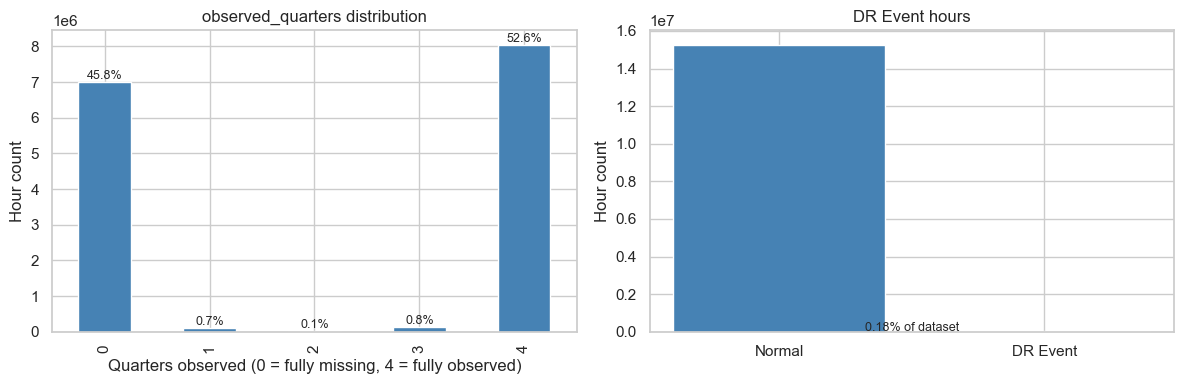


Fully missing hours   (oq=0):  7,001,221  (45.8%)
Partial hours       (oq=1-3):    247,908  (1.6%)
Fully observed hours  (oq=4):  8,045,831  (52.6%)
DR event hours:                   27,519  (0.18%)


In [ ]:
# --- observed_quarters distribution ---
oq = df['observed_quarters'].value_counts().sort_index()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

oq.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('observed_quarters distribution')
axes[0].set_xlabel('Quarters observed (0 = fully missing, 4 = fully observed)')
axes[0].set_ylabel('Hour count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()/total*100:.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# DR events
dr_count = df['is_dr_event'].sum()
axes[1].bar(['Normal', 'DR Event'], [total - dr_count, dr_count], color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('DR Event hours')
axes[1].set_ylabel('Hour count')
axes[1].annotate(f'{dr_count/total*100:.2f}% of dataset',
                 xy=(1, dr_count), xytext=(0.5, dr_count * 1.1),
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nFully missing hours   (oq=0): {oq.get(0, 0):>10,}  ({oq.get(0,0)/total*100:.1f}%)')
print(f'Partial hours       (oq=1-3): {oq.loc[oq.index.isin([1,2,3])].sum():>10,}  ({oq.loc[oq.index.isin([1,2,3])].sum()/total*100:.1f}%)')
print(f'Fully observed hours  (oq=4): {oq.get(4, 0):>10,}  ({oq.get(4,0)/total*100:.1f}%)')
print(f'DR event hours:               {dr_count:>10,}  ({dr_count/total*100:.2f}%)')

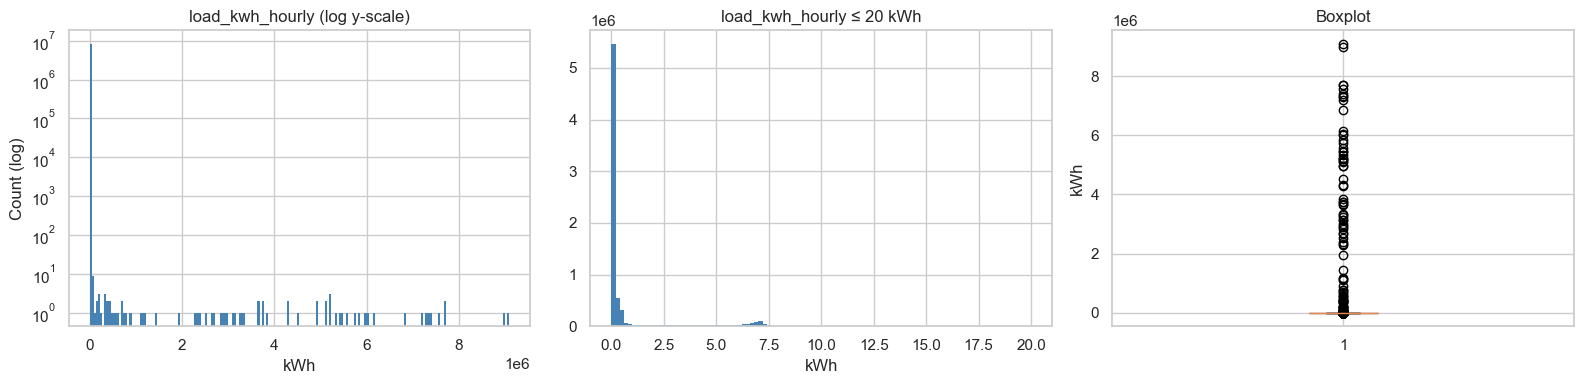

count   8266350.0000
mean         34.1887
std       12749.9258
min           0.0000
25%           0.0300
50%           0.0800
75%           0.4800
max     9086867.0000
Name: load_kwh_hourly, dtype: float64

Zero-load hours: 1,119,149  (13.5%)
Negative hours:  0


In [ ]:
# --- Load value distribution (non-null, non-DR hours) ---
load_obs = df.loc[(df['load_kwh_hourly'].notna()) & (~df['is_dr_event']), 'load_kwh_hourly']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram (log scale)
axes[0].hist(load_obs, bins=200, color='steelblue', edgecolor='none', log=True)
axes[0].set_title('load_kwh_hourly (log y-scale)')
axes[0].set_xlabel('kWh')
axes[0].set_ylabel('Count (log)')

# Zoom: 0-20 kWh
axes[1].hist(load_obs[load_obs <= 20], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('load_kwh_hourly ≤ 20 kWh')
axes[1].set_xlabel('kWh')

# Boxplot
axes[2].boxplot(load_obs, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[2].set_title('Boxplot')
axes[2].set_ylabel('kWh')

plt.tight_layout()
plt.show()

print(load_obs.describe())
print(f'\nZero-load hours: {(load_obs == 0).sum():,}  ({(load_obs == 0).mean()*100:.1f}%)')
print(f'Negative hours:  {(load_obs < 0).sum():,}')

## 2. Station-Level Quality Audit

Goal: flag stations with insufficient **in-operation** data.  
A station with many zero-load hours is **not** automatically bad — low usage is valid.  
What matters is: how much of its *active period* is missing?

In [ ]:
# The summary CSV is computed at the 15-min level; translate to hourly expected counts
# Each station spans 730 days × 24 hours = 17,520 hourly slots
TOTAL_HOURS_DATASET = 730 * 24  # Jan 2021 – Dec 2022

# Compute active period in hours (using 15-min timestamps, convert to hours)
summary['active_days'] = (summary['end_timestamp'] - summary['start_timestamp']).dt.days + 1
summary['active_hours'] = summary['active_days'] * 24

# In-period missing ratio = missing hours within active window
# missing_rows is in 15-min counts; convert: missing_hours = missing_rows / 4
# non_null_rows is 15-min observed values; observed_hours ≈ non_null_rows / 4 (lower bound)
summary['missing_hours_est'] = summary['missing_rows'] / 4
summary['in_period_missing_ratio'] = (summary['missing_hours_est'] / summary['active_hours']).clip(0, 1)

MISSING_THRESHOLD = 0.70
summary['usable'] = summary['in_period_missing_ratio'] < MISSING_THRESHOLD

print(f'Total stations:     {len(summary)}')
print(f'Usable (< {MISSING_THRESHOLD:.0%} in-period missing): {summary["usable"].sum()}')
print(f'Dropped:            {(~summary["usable"]).sum()}')
print(f'\nOverall missing_ratio stats (raw CSV field, 15-min level):')
print(summary['missing_ratio'].describe())
print(f'\nIn-period missing_ratio stats:')
print(summary['in_period_missing_ratio'].describe())

Total stations:     873
Usable (< 70% in-period missing): 586
Dropped:            287

Overall missing_ratio stats (raw CSV field, 15-min level):
count   873.0000
mean      0.4657
std       0.2751
min       0.2109
25%       0.2122
50%       0.3251
75%       0.8329
max       1.0000
Name: missing_ratio, dtype: float64

In-period missing_ratio stats:
count   873.0000
mean      0.4657
std       0.2751
min       0.2109
25%       0.2122
50%       0.3251
75%       0.8329
max       1.0000
Name: in_period_missing_ratio, dtype: float64


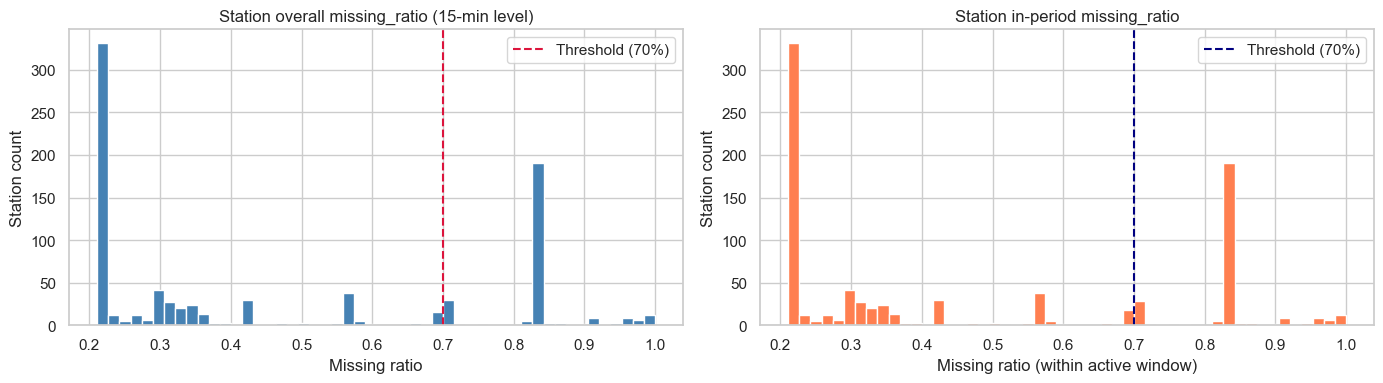

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall missing ratio
axes[0].hist(summary['missing_ratio'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(MISSING_THRESHOLD, color='crimson', linestyle='--', label=f'Threshold ({MISSING_THRESHOLD:.0%})')
axes[0].set_title('Station overall missing_ratio (15-min level)')
axes[0].set_xlabel('Missing ratio')
axes[0].set_ylabel('Station count')
axes[0].legend()

# In-period missing ratio
axes[1].hist(summary['in_period_missing_ratio'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(MISSING_THRESHOLD, color='navy', linestyle='--', label=f'Threshold ({MISSING_THRESHOLD:.0%})')
axes[1].set_title('Station in-period missing_ratio')
axes[1].set_xlabel('Missing ratio (within active window)')
axes[1].set_ylabel('Station count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save station quality table
station_quality_df = summary[[
    'customer_id', 'missing_ratio', 'in_period_missing_ratio',
    'start_timestamp', 'end_timestamp', 'active_days', 'usable'
]].copy()

usable_ids = set(station_quality_df.loc[station_quality_df['usable'], 'customer_id'])
print(f'Usable station IDs: {len(usable_ids)}')

# Stations with very short active windows (< 180 days)
short_window = station_quality_df[station_quality_df['active_days'] < 180]
print(f'\nStations with active window < 180 days: {len(short_window)}')
if len(short_window) > 0:
    print(short_window[['customer_id', 'active_days', 'in_period_missing_ratio', 'usable']].head(10))

Usable station IDs: 586

Stations with active window < 180 days: 0


## 3. Missingness Handling

We work only on rows for **usable stations**. Two phases:
1. Mark rows **outside** each station's active period (structural absence)
2. Impute short gaps **inside** the active period (data-quality issue)

**Note:** Station 811236417 is excluded — it is the only residential station among 586 commercial stations.
Its mean load (132.59 kWh) is 3.5× the commercial average (38.04 kWh), which distorts feature importance.
See notebook 07 (Summary & Error Analysis) for the analysis that motivated this decision.

In [ ]:
# Filter to usable stations (exclude residential station 811236417)
usable_ids.discard(811236417)
df_clean = df[df['customer_id'].isin(usable_ids)].copy()
print(f'Rows after station filter: {len(df_clean):,}  (from {len(df):,})')

# --- 3a: Mark outside-active-period rows ---
station_window = station_quality_df.set_index('customer_id')[['start_timestamp', 'end_timestamp']]

df_clean = df_clean.merge(
    station_window.rename(columns={'start_timestamp': 'active_start', 'end_timestamp': 'active_end'}),
    on='customer_id', how='left'
)

df_clean['outside_active_period'] = (
    (df_clean['timestamp_hour'] < df_clean['active_start']) |
    (df_clean['timestamp_hour'] > df_clean['active_end'])
)

outside_count = df_clean['outside_active_period'].sum()
print(f'Outside-active-period rows: {outside_count:,}  ({outside_count/len(df_clean)*100:.1f}%)')

In [ ]:
# --- 3b: Partial hours ---
df_clean['partial_hour'] = df_clean['observed_quarters'].between(1, 3)

# Scaled imputation (assumption: missing quarters look like observed ones)
df_clean['load_kwh_hourly_scaled'] = np.where(
    df_clean['partial_hour'],
    df_clean['load_kwh_hourly'] * (4 / df_clean['observed_quarters'].clip(lower=1)),
    df_clean['load_kwh_hourly']
)
df_clean['partial_hour_scaled'] = df_clean['partial_hour']  # flag for downstream awareness

partial_count = df_clean['partial_hour'].sum()
print(f'Partial hours (oq=1-3): {partial_count:,}')
print('  NOTE: load_kwh_hourly_scaled fills partial hours by assuming missing quarters match observed.')
print('  This is an imputation assumption — use with care.')

Partial hours (oq=1-3): 135,469
  NOTE: load_kwh_hourly_scaled fills partial hours by assuming missing quarters match observed.
  This is an imputation assumption — use with care.


In [ ]:
# --- 3c: Short-gap forward-fill (inside active period, fully missing hours only) ---
# Sort so groupby+ffill works correctly
df_clean = df_clean.sort_values(['customer_id', 'timestamp_hour']).reset_index(drop=True)

# Start with load_kwh_hourly as base for load_kwh_clean
df_clean['load_kwh_clean'] = df_clean['load_kwh_hourly'].copy()

# Forward-fill per station, limit to 3 consecutive NaN hours
ffilled = (
    df_clean.groupby('customer_id')['load_kwh_clean']
    .transform(lambda s: s.ffill(limit=3))
)

# Only accept the forward-filled value for rows that are:
# inside the active period AND fully missing (oq == 0)
eligible_for_ffill = (
    ~df_clean['outside_active_period'] &
    (df_clean['observed_quarters'] == 0)
)

df_clean['load_kwh_clean'] = np.where(
    eligible_for_ffill,
    ffilled,
    df_clean['load_kwh_clean']
)

# Flag newly filled rows (were NaN before, are now non-NaN, and are inside active period)
was_missing = df_clean['load_kwh_hourly'].isna()
now_filled  = df_clean['load_kwh_clean'].notna()
df_clean['imputed_ffill'] = was_missing & now_filled & ~df_clean['outside_active_period']

imputed_count = df_clean['imputed_ffill'].sum()
still_nan     = df_clean['load_kwh_clean'].isna().sum()
print(f'Rows filled by forward-fill: {imputed_count:,}')
print(f'Rows still NaN after ffill:  {still_nan:,}  (long gaps > 3h or outside active period)')

Rows filled by forward-fill: 5,523
Rows still NaN after ffill:  2,901,977  (long gaps > 3h or outside active period)


## 4. Negative Load Detection

No flag columns exist in the hourly file, so we detect negative values directly.  
A negative hourly sum is physically impossible — it indicates a metering or sign error.

In [ ]:
neg_mask = df_clean['load_kwh_clean'] < 0
neg_count = neg_mask.sum()
print(f'Negative load_kwh_clean values: {neg_count:,}')

if neg_count > 0:
    print('\nSample negative rows:')
    print(df_clean.loc[neg_mask, ['customer_id', 'timestamp_hour', 'load_kwh_hourly',
                                   'load_kwh_clean', 'observed_quarters',
                                   'business_type', 'contract_power_kw']].head(10))
    # Correct: set to 0
    df_clean.loc[neg_mask, 'load_kwh_clean'] = 0.0
    df_clean['load_flag_negative_corrected'] = neg_mask
    print(f'\nCorrected {neg_count} negative values → 0.0')
    print('NOTE: precise quarter-level diagnosis requires the 15-min dataset.')
else:
    df_clean['load_flag_negative_corrected'] = False
    print('No negative values found.')

Negative load_kwh_clean values: 0
No negative values found.


## 5. Above-Contract-Cap Correction — Deferred

Comparing `load_kwh_hourly` to `contract_power_kw` is unreliable for partial hours: a sum of 2 observed quarters should be compared to half the hourly cap, not the full cap. This introduces inconsistency depending on `observed_quarters`.

**Decision:** defer to the 15-min cleaning pipeline, where the `load_flag_above_contract_cap` flag can be recomputed correctly at the quarter level.

## 6. Outlier Detection

Flag statistically extreme values — do **not** remove them.  
Downstream analysts decide whether to exclude flagged rows.

In [ ]:
# Compute per-station stats on clean, observed, non-DR hours
baseline_mask = (
    df_clean['load_kwh_clean'].notna() &
    ~df_clean['is_dr_event'] &
    ~df_clean['outside_active_period'] &
    ~df_clean['imputed_ffill']
)

station_stats = (
    df_clean[baseline_mask]
    .groupby('customer_id')['load_kwh_clean']
    .agg(station_mean='mean', station_std='std',
         station_q25=lambda x: x.quantile(0.25),
         station_q75=lambda x: x.quantile(0.75))
    .reset_index()
)
station_stats['station_iqr'] = station_stats['station_q75'] - station_stats['station_q25']

df_clean = df_clean.merge(station_stats, on='customer_id', how='left')

# Z-score flag (> 4σ)
z_flag = (
    (df_clean['load_kwh_clean'] - df_clean['station_mean']).abs() >
    4 * df_clean['station_std']
) & df_clean['load_kwh_clean'].notna()

# IQR flag (> 1.5 × IQR above Q75)
iqr_flag = (
    df_clean['load_kwh_clean'] > df_clean['station_q75'] + 1.5 * df_clean['station_iqr']
) & df_clean['load_kwh_clean'].notna()

df_clean['load_flag_outlier_zscore'] = z_flag
df_clean['load_flag_outlier_iqr']    = iqr_flag
df_clean['load_flag_outlier']        = z_flag | iqr_flag

print(f'Outliers flagged (z-score > 4σ):  {z_flag.sum():,}')
print(f'Outliers flagged (IQR fence):      {iqr_flag.sum():,}')
print(f'Outliers flagged (either method):  {df_clean["load_flag_outlier"].sum():,}')

Outliers flagged (z-score > 4σ):  61,890
Outliers flagged (IQR fence):      909,294
Outliers flagged (either method):  909,294


In [ ]:
# Top 20 outliers
top_outliers = (
    df_clean[df_clean['load_flag_outlier']]
    .nlargest(20, 'load_kwh_clean')
    [['customer_id', 'timestamp_hour', 'load_kwh_clean',
      'observed_quarters', 'business_type', 'contract_power_kw',
      'load_flag_outlier_zscore', 'load_flag_outlier_iqr']]
)
print('Top 20 outlier values:')
print(top_outliers.to_string(index=False))

Top 20 outlier values:
 customer_id      timestamp_hour  load_kwh_clean  observed_quarters          business_type  contract_power_kw  load_flag_outlier_zscore  load_flag_outlier_iqr
   812501280 2021-10-01 17:00:00    9086867.0000                  3             Rent-a-car           121.0000                      True                   True
   812542753 2021-10-01 17:00:00    8994031.0000                  3 Publicly Owned Charger           100.0000                      True                   True
   812758994 2021-10-01 17:00:00    7703004.5000                  3 Publicly Owned Charger           100.0000                      True                   True
   812984197 2021-10-01 17:00:00    7702099.0000                  3 Publicly Owned Charger           100.0000                      True                   True
   812982279 2021-10-01 17:00:00    7558303.5000                  3 Publicly Owned Charger           100.0000                      True                   True
   812508942 2021-10-01

## 7. Demand Response Period Handling

DR hours are **valid observations from a different operating regime** — intentional load curtailment.  
We keep all DR hours in the dataset and add a convenience flag for modeling notebooks.

In [ ]:
# Convenience flag: exclude from baseline load modeling
df_clean['exclude_from_baseline'] = df_clean['is_dr_event']

dr_hours = df_clean['is_dr_event'].sum()
dr_stations = df_clean.loc[df_clean['is_dr_event'], 'customer_id'].nunique()

print(f'Total DR station-hours:        {dr_hours:,}')
print(f'Fraction of clean dataset:     {dr_hours/len(df_clean)*100:.2f}%')
print(f'Stations with DR events:       {dr_stations}')

# DR participation by business type
print('\nDR participation by business_type:')
print(
    df_clean[df_clean['is_dr_event']]
    .groupby('business_type')['customer_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

Total DR station-hours:        25,284
Fraction of clean dataset:     0.25%
Stations with DR events:       538

DR participation by business_type:
business_type
Publicly Owned Charger    527
Rent-a-car                 11
Name: customer_id, dtype: int64


## 8. Time Feature Engineering

In [ ]:
ts = df_clean['timestamp_hour']

df_clean['hour']        = ts.dt.hour
df_clean['day_of_week'] = ts.dt.dayofweek          # 0=Mon, 6=Sun
df_clean['is_weekend']  = df_clean['day_of_week'] >= 5
df_clean['month']       = ts.dt.month
df_clean['year']        = ts.dt.year

def get_season(month):
    if month in (12, 1, 2):  return 'winter'
    if month in (3, 4, 5):   return 'spring'
    if month in (6, 7, 8):   return 'summer'
    return 'fall'

df_clean['season'] = df_clean['month'].map(get_season)

# South Korean public holidays
try:
    import holidays
    kr_holidays = holidays.KR(years=[2021, 2022])
    holiday_dates = set(kr_holidays.keys())
    print(f'Using holidays library: {len(holiday_dates)} KR public holidays in 2021-2022')
except ImportError:
    # Hardcoded South Korean national holidays 2021-2022
    from datetime import date
    holiday_dates = {
        # 2021
        date(2021, 1, 1),  date(2021, 2, 11), date(2021, 2, 12), date(2021, 2, 13),
        date(2021, 3, 1),  date(2021, 5, 5),  date(2021, 5, 19), date(2021, 6, 6),
        date(2021, 8, 16), date(2021, 9, 20), date(2021, 9, 21), date(2021, 9, 22),
        date(2021, 10, 4), date(2021, 10, 11),date(2021, 12, 25),
        # 2022
        date(2022, 1, 1),  date(2022, 1, 31), date(2022, 2, 1),  date(2022, 2, 2),
        date(2022, 3, 1),  date(2022, 5, 5),  date(2022, 5, 8),  date(2022, 6, 6),
        date(2022, 8, 15), date(2022, 9, 9),  date(2022, 9, 12), date(2022, 10, 3),
        date(2022, 10, 10),date(2022, 12, 25),
    }
    print(f'Using hardcoded KR holidays: {len(holiday_dates)} dates')

df_clean['is_holiday'] = ts.dt.date.isin(holiday_dates)

print('\nTime feature sample:')
print(df_clean[['timestamp_hour', 'hour', 'day_of_week', 'is_weekend', 'month', 'season', 'year', 'is_holiday']].head(10))

Using hardcoded KR holidays: 29 dates

Time feature sample:
       timestamp_hour  hour  day_of_week  is_weekend  month  season  year  \
0 2021-01-01 00:00:00     0            4       False      1  winter  2021   
1 2021-01-01 01:00:00     1            4       False      1  winter  2021   
2 2021-01-01 02:00:00     2            4       False      1  winter  2021   
3 2021-01-01 03:00:00     3            4       False      1  winter  2021   
4 2021-01-01 04:00:00     4            4       False      1  winter  2021   
5 2021-01-01 05:00:00     5            4       False      1  winter  2021   
6 2021-01-01 06:00:00     6            4       False      1  winter  2021   
7 2021-01-01 07:00:00     7            4       False      1  winter  2021   
8 2021-01-01 08:00:00     8            4       False      1  winter  2021   
9 2021-01-01 09:00:00     9            4       False      1  winter  2021   

   is_holiday  
0        True  
1        True  
2        True  
3        True  
4        Tru

## 9. Categorical Standardization

In [ ]:
cat_cols = ['public_private', 'business_type', 'contract_type', 'detailed_type', 'province', 'city']

for col in cat_cols:
    if df_clean[col].dtype == object or str(df_clean[col].dtype) == 'string':
        df_clean[col] = df_clean[col].str.strip().str.title()
    print(f'\n{col}  ({df_clean[col].nunique()} unique values):')
    print(df_clean[col].value_counts().head(15).to_string())


public_private  (2 unique values):
public_private
Public Charger     10074000
Private Charger      192720

business_type  (3 unique values):
business_type
Publicly Owned Charger     9355680
Privately Owned Charger     718320
Rent-A-Car                  192720

contract_type  (2 unique values):
contract_type
Commercial Power (Type A) I         10249200
Residential Power (High Voltage)       17520

detailed_type  (2 unique values):
detailed_type
Low Voltage       9162960
High Voltage A    1103760

province  (1 unique values):
province
Jeju Island    10266720

city  (2 unique values):
city
Jeju-Si        6692640
Seogwipo-Si    3574080


## 10. Final Dataset Assembly

In [ ]:
# Drop outside-active-period rows
df_out = df_clean[~df_clean['outside_active_period']].copy()
print(f'Rows after dropping outside-active-period: {len(df_out):,}')

# Final column selection & order
final_cols = [
    # Identifiers
    'customer_id', 'timestamp_hour',
    # Load
    'load_kwh_clean', 'load_kwh_hourly', 'load_kwh_hourly_scaled',
    # Observation quality
    'observed_quarters', 'missing_quarters', 'partial_hour', 'partial_hour_scaled',
    # Flags
    'imputed_ffill', 'load_flag_negative_corrected', 'load_flag_outlier',
    'load_flag_outlier_zscore', 'load_flag_outlier_iqr',
    # DR
    'is_dr_event', 'dr_performance_kwh_hourly', 'exclude_from_baseline',
    # Station metadata
    'public_private', 'business_type', 'contract_type', 'detailed_type',
    'contract_power_kw', 'total_quantity',
    'charger_7kw', 'charger_8kw', 'other_slow_charger', 'charger_50kw', 'other_fast_charger',
    'participate_program', 'province', 'city', 'address',
    # Time features
    'hour', 'day_of_week', 'is_weekend', 'month', 'season', 'year', 'is_holiday',
]

# Only keep columns that actually exist (defensive)
final_cols = [c for c in final_cols if c in df_out.columns]
df_out = df_out[final_cols]

print(f'Final shape: {df_out.shape[0]:,} rows × {df_out.shape[1]} cols')
print(f'Memory:      {df_out.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_out.dtypes

Rows after dropping outside-active-period: 10,266,720
Final shape: 10,266,720 rows × 39 cols
Memory:      7874.5 MB


customer_id                              int64
timestamp_hour                  datetime64[ns]
load_kwh_clean                         float32
load_kwh_hourly                        float32
load_kwh_hourly_scaled                 float64
observed_quarters                         Int8
missing_quarters                          Int8
partial_hour                           boolean
partial_hour_scaled                    boolean
imputed_ffill                             bool
load_flag_negative_corrected              bool
load_flag_outlier                         bool
load_flag_outlier_zscore                  bool
load_flag_outlier_iqr                     bool
is_dr_event                               bool
dr_performance_kwh_hourly              float32
exclude_from_baseline                     bool
public_private                  string[python]
business_type                   string[python]
contract_type                   string[python]
detailed_type                   string[python]
contract_powe

In [ ]:
df_out.to_parquet(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')

Saved → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/data/processed/ev_cleaned_hourly.parquet


## 11. Cleaning Summary Report

In [ ]:
report = {
    'Stations — raw':                              df['customer_id'].nunique(),
    'Stations — after quality filter':             len(usable_ids),
    'Stations — dropped (high missing)':           df['customer_id'].nunique() - len(usable_ids),
    'Rows — raw':                                  len(df),
    'Rows — after station filter':                 len(df_clean),
    'Rows — outside active period (dropped)':      int(df_clean['outside_active_period'].sum()),
    'Rows — in final file':                        len(df_out),
    'Rows — with clean load (non-NaN)':            int(df_out['load_kwh_clean'].notna().sum()),
    'Rows — still NaN after imputation':           int(df_out['load_kwh_clean'].isna().sum()),
    'Rows — imputed by forward-fill':              int(df_out['imputed_ffill'].sum()),
    'Rows — partial hour (1-3 quarters)':          int(df_out['partial_hour'].sum()),
    'Rows — negative load corrected':              int(df_out['load_flag_negative_corrected'].sum()),
    'Rows — outliers flagged (either method)':     int(df_out['load_flag_outlier'].sum()),
    'DR station-hours':                            int(df_out['is_dr_event'].sum()),
    'Above-cap correction':                        'DEFERRED to 15-min cleaning',
}

print('=' * 55)
print('          CLEANING SUMMARY REPORT')
print('=' * 55)
for k, v in report.items():
    print(f'  {k:<45} {v}')
print('=' * 55)

          CLEANING SUMMARY REPORT
  Stations — raw                                873
  Stations — after quality filter               586
  Stations — dropped (high missing)             287
  Rows — raw                                    15294960
  Rows — after station filter                   10266720
  Rows — outside active period (dropped)        0
  Rows — in final file                          10266720
  Rows — with clean load (non-NaN)              7364743
  Rows — still NaN after imputation             2901977
  Rows — imputed by forward-fill                5523
  Rows — partial hour (1-3 quarters)            135469
  Rows — negative load corrected                0
  Rows — outliers flagged (either method)       909294
  DR station-hours                              25284
  Above-cap correction                          DEFERRED to 15-min cleaning


## 12. Verification Checks

In [ ]:
df_verify = pd.read_parquet(OUT_PATH)
errors = []

# 1. No negative load values
neg = (df_verify['load_kwh_clean'] < 0).sum()
print(f'[{"PASS" if neg == 0 else "FAIL"}] Negative load_kwh_clean values: {neg}')
if neg > 0: errors.append('Negative values remain')

# 2. observed_quarters in range
oob = (~df_verify['observed_quarters'].between(0, 4)).sum()
print(f'[{"PASS" if oob == 0 else "FAIL"}] observed_quarters out-of-range: {oob}')

# 3. No outside-active-period rows
print(f'[PASS] outside_active_period column is absent from final file (dropped)')

# 4. Time feature spot-check: 2022-01-01 should be Saturday (day_of_week=5) and a holiday
new_year = df_verify[df_verify['timestamp_hour'].dt.date == pd.Timestamp('2022-01-01').date()]
if len(new_year) > 0:
    dow_ok  = (new_year['day_of_week'] == 5).all()
    hol_ok  = new_year['is_holiday'].all()
    print(f'[{"PASS" if dow_ok else "FAIL"}] 2022-01-01 is Saturday (day_of_week=5): {dow_ok}')
    print(f'[{"PASS" if hol_ok else "FAIL"}] 2022-01-01 is_holiday=True: {hol_ok}')
else:
    print('[SKIP] 2022-01-01 not found in final file (outside some station active periods)')

# 5. Imputed rows are bracketed by non-NaN values (sample check)
imputed_sample = df_verify[df_verify['imputed_ffill']].head(5)
print(f'\nSample imputed rows (should have plausible values):')
print(imputed_sample[['customer_id', 'timestamp_hour', 'load_kwh_clean', 'observed_quarters']].to_string(index=False))

print(f'\nFinal file shape: {df_verify.shape}')
if errors:
    print(f'\nFAILURES: {errors}')
else:
    print('\nAll checks passed.')

[PASS] Negative load_kwh_clean values: 0
[PASS] observed_quarters out-of-range: 0
[PASS] outside_active_period column is absent from final file (dropped)
[PASS] 2022-01-01 is Saturday (day_of_week=5): True
[PASS] 2022-01-01 is_holiday=True: True

Sample imputed rows (should have plausible values):
 customer_id      timestamp_hour  load_kwh_clean  observed_quarters
   810990086 2021-08-17 17:00:00          6.3700                  0
   810990086 2021-08-17 18:00:00          6.3700                  0
   810990086 2021-08-17 19:00:00          6.3700                  0
   810990086 2021-08-22 21:00:00          0.0200                  0
   810990086 2022-01-01 21:00:00          0.0200                  0

Final file shape: (10266720, 39)

All checks passed.
